# 🪐 CoolTrack: Machine Learning Planetary Evolution

Welcome to **CoolTrack**, a high-performance framework designed to rapidly compute evolutionary cooling tracks for giant planets and brown dwarfs. 

Simulating the thermal evolution of a planet across billions of years using standard 1D structural codes is incredibly slow, as the solver must iteratively step through time while recalculating the interior structure at every tick. `cooltrack` bypasses this by training a fast, differentiable **Machine Learning Surrogate** (XGBoost) on a massive pre-computed grid (like the ones generated by `exoweave`). It then uses this ML engine to evaluate the planet's cooling rate on the fly, integrating the age via SciPy.


---

## 1. The Physics and Mathematics of ML Evolution

### 1.1 The Inverted Ordinary Differential Equation (ODE)
Normally, evolution codes integrate temperature forward in time ($dt$). However, the ML surrogate predicts the absolute cooling rate ($dS/dt$) as a function of the planet's fixed parameters and its current specific entropy ($S$). 

To find the age of a planet at a specific state, we invert the problem. We integrate *time* over the domain of *entropy*:

$$\frac{dt}{dS} = \frac{-1}{|dS/dt|}$$

The `CoolingIntegrator` uses a 4th-order Runge-Kutta solver (`solve_ivp`) to integrate this equation from a high "hot-start" entropy ($S_0$) down to the target entropy ($S_{final}$).

### 1.2 Boundary Conditions (Hot/Cold Starts)
To know where to start the integration ($S_0$), the package uses the `InitialConditions` module. It loads theoretical mass-entropy relationships for newly formed planets and creates bounding interpolators. A "Hot Start" represents a planet formed via rapid gravitational collapse, while a "Cold Start" represents core accretion.

### 1.3 ML Step Functions and Signal Smoothing
Because `cooltrack` utilizes XGBoost (an ensemble of decision trees), its raw predictions are inherently discrete step functions. If integrated directly, the resulting cooling track will look like a jagged staircase. To restore physical realism, the `TrackSmoother` module applies mathematical filters—such as Savitzky-Golay or B-Splines—to smooth the arrays while preserving their thermodynamic derivatives.

---
## 2. Data Loading & Preprocessing

The first step in using `cooltrack` is loading the raw grid data. The `data_loader.py` module acts as a universal adapter. It can ingest raw Parquet grids or parse the massive HDF5 hierarchical databases generated by the `exoweave` compiler.

During loading, it automatically filters out unphysical artifacts, scales units, and safely computes the base-10 logarithm of the cooling rate ($\log_{10} |dS/dt|$) and photometric fluxes for better ML gradient descent.

In [3]:
import pandas as pd
from cooltrack.data_loader import load_grid
from cooltrack.constants import INDEPENDENT_DIMS, PHOTOMETRY_BANDS

# 1. Load the compiled ExoWeave grid
# The loader automatically detects the .h5 format and applies the CT scaling!
print("📥 Loading planetary grid...")
df_clean = load_grid("../../exoweave/outputs/master_grid_data.h5")

# Inspect the ML feature space
print(f"Dataset shape: {df_clean.shape}")
print("Features used for prediction:", INDEPENDENT_DIMS + ['S_physical'])

2026-03-08 21:30:05,997 - INFO - Loading Exoweave HDF5 file: ../../exoweave/outputs/master_grid_data.h5...


📥 Loading planetary grid...


2026-03-08 21:30:30,258 - INFO - ✅ Exoweave Grid loaded and mapped successfully. Final shape: (3522, 43)


Dataset shape: (3522, 43)
Features used for prediction: ['mass_Mj', 'T_irr', 'Met', 'core', 'f_sed', 'kzz', 'S_physical']


---
## 3. Training the Machine Learning Surrogate

The `ThermalEvolutionModels` class orchestrates the XGBoost regressors. It trains separate, highly-optimized models to predict $T_{int}$, Planetary Radius ($R_{eq}$), the cooling rate ($dS/dt$), and all JWST/HST photometric bands. 

It also includes a built-in outlier rejection pass: it does a fast preliminary training run, checks the residuals, and drops any grid points that severely violate the local thermodynamic trends (usually due to 1D solver non-convergence).

In [4]:
from cooltrack.models import ThermalEvolutionModels

# 1. Initialize the ML Engine
ml_engine = ThermalEvolutionModels()

# 2. Train the models (Warning: Can take several minutes on massive grids!)
# clean_outliers=True will drop points with >1.0 dex error in the first pass
print("🧠 Training XGBoost surrogates...")
df_training = ml_engine.train_models(df_clean, clean_outliers=True)

# 3. Save the trained models to disk so we don't have to retrain next time!
ml_engine.save_models("../data/models/")

2026-03-08 21:30:31,140 - INFO - Performing first-pass training to identify grid outliers...
2026-03-08 21:30:31,312 - INFO - No massive outliers found in the grid.
2026-03-08 21:30:31,314 - INFO - Training T_int and Radius state models...


🧠 Training XGBoost surrogates...


2026-03-08 21:30:32,277 - INFO - Training 15 photometric band models (this will take a minute)...
2026-03-08 21:30:35,926 - INFO - All photometry models trained successfully!
2026-03-08 21:30:35,930 - INFO - Training final baseline dS/dt model...
2026-03-08 21:30:36,834 - INFO - Final dS/dt test R^2: 0.9701
2026-03-08 21:30:36,835 - INFO - Saving models to ../data/models/...
2026-03-08 21:30:37,465 - INFO - All models saved successfully.


---
## 4. Integration & Track Smoothing

Once the ML engine is trained (or loaded from disk), we initialize the physical boundary conditions and the ODE solver. We can then ask the integrator to generate a full, continuous time-evolution track for any planet in the dataset.

2026-03-08 21:30:37,942 - INFO - Loaded initial condition interpolators from 4 files.


🪐 Evolving a 0.46 M_Jup planet...
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


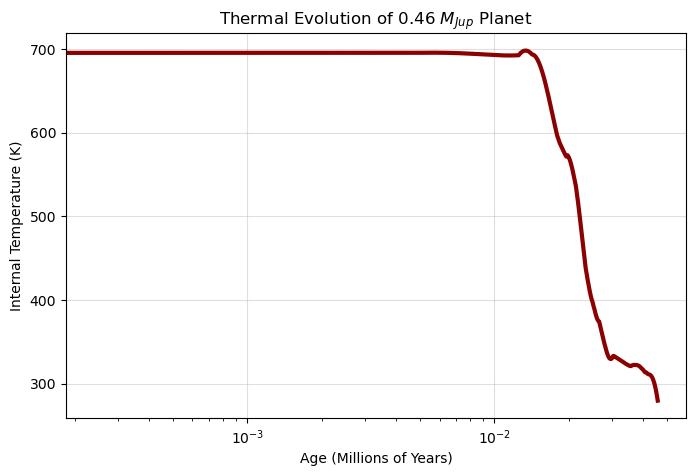

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from cooltrack.initial_conditions import InitialConditions
from cooltrack.integrator import CoolingIntegrator
from cooltrack.smoothing import TrackSmoother

# 1. Setup the Physics Engine
init_cond = InitialConditions("../data/age_data/")
integrator = CoolingIntegrator(ml_engine)

# 2. Pick a random planet from our dataset to evolve
sample_planet = df_training.iloc[0]
mass = sample_planet['mass_Mj']
s_target = sample_planet['S_physical']

print(f"🪐 Evolving a {mass:.2f} M_Jup planet...")

# 3. Get the Hot-Start entropy for this specific mass
s_hot_start = init_cond.get_starting_physical_entropy(mass, bin_index=19)

# 4. Integrate the ODE to generate the cooling track!
ages_yr, entropies = integrator.calculate_track(
    sample_planet, 
    s0_initial=s_hot_start, 
    s_final=s_target, 
    num_points=200
)

# 5. Predict the corresponding T_int for every entropy step using the ML
# (We stack the fixed parameters with the changing entropy array)
fixed_params = sample_planet[['mass_Mj', 'T_irr', 'Met', 'core', 'f_sed', 'kzz']].values.astype(float)
state_vectors = np.column_stack((np.tile(fixed_params, (len(entropies), 1)), entropies))

raw_tints = ml_engine.tint_model.predict(state_vectors)

# 6. Apply Signal Processing to remove ML tree-step artifacts
smooth_tints = TrackSmoother.smooth(x=ages_yr, y=raw_tints, method='savgol', window_length=31)

# Plot the smooth evolution!
plt.figure(figsize=(8, 5))
plt.plot(ages_yr / 1e6, smooth_tints, lw=3, color='darkred')
plt.xlabel("Age (Millions of Years)")
plt.ylabel("Internal Temperature (K)")
plt.title(f"Thermal Evolution of {mass:.2f} $M_{{Jup}}$ Planet")
plt.xscale('log')
plt.grid(True, alpha=0.4)
plt.show()

---
## 5. Large-Scale Processing: The Master Pipeline

If you want to calculate the age of every single planet in a $50,000+$ point grid, doing it sequentially in a notebook will take hours. 

The `cooltrack` package provides a highly optimized master script located at `scripts/main.py`. This script represents the end-to-end workflow:

1. **Smart Caching:** It checks if models are already trained and saved in `../data/models/`. If so, it bypasses the heavy XGBoost training entirely.
2. **Parallel CPU Dispatch:** It loads the data, initializes the ODE integrator, and uses `joblib.Parallel` to dispatch the `compute_age` function across all available CPU cores simultaneously.
3. **Data Export:** It appends the exact calculated `Age_yr` to the dataframe and exports a finalized, machine-learning-ready Parquet file.

You can execute it directly from your terminal:

In [2]:
# To run the master pipeline, execute this in your terminal:
# $ python scripts/main.py

# Expected Output:
"""
==================================================
🚀 COOLTRACK MASTER PIPELINE INITIALIZED 🚀
==================================================
INFO: Found pre-trained models and clean grid! Skipping training...
INFO: Initializing Initial Conditions and ODE Integrator...
INFO: Firing up parallel age computation across CPU cores...
Calculating Ages: 100%|████████████████| 54200/54200 [01:42<00:00, 529.11 planet/s]
INFO: Saving final grid with ages to ../data/HADES_grid/hades_grid_with_ages.parquet...

==================================================
✅ PIPELINE COMPLETE! ✅
Total simulated planets saved: 54,200
==================================================
"""

'\n==================================================\n🚀 COOLTRACK MASTER PIPELINE INITIALIZED 🚀\n==================================================\nINFO: Found pre-trained models and clean grid! Skipping training...\nINFO: Initializing Initial Conditions and ODE Integrator...\nINFO: Firing up parallel age computation across CPU cores...\nCalculating Ages: 100%|████████████████| 54200/54200 [01:42<00:00, 529.11 planet/s]\nINFO: Saving final grid with ages to ../data/HADES_grid/hades_grid_with_ages.parquet...\n\n==================================================\n✅ PIPELINE COMPLETE! ✅\nTotal simulated planets saved: 54,200\n==================================================\n'